# NB05: Tryptophan → IAA Coupling (H4)

**Hypothesis H4**: Tryptophan biosynthesis pathway completeness (GapMind score) predicts the presence of ipdC (indole-3-pyruvate decarboxylase), because IAA biosynthesis via the IPyA pathway requires tryptophan as a substrate.

**Steps:**
1. Cross-tabulation: trp_complete × ipdC_present → Fisher's exact test
2. Logistic regression: `ipdC_present ~ trp_complete + env_soil + phylum`
3. Stratified analysis: does coupling differ in soil vs non-soil genomes?
4. Negative control: tyr completeness should NOT predict ipdC

**Input**: `data/trp_completeness.csv`, `data/species_pgp_matrix.csv`, `data/species_environment.csv`

**Output**: `data/trp_iaa_results.csv`, `figures/trp_iaa_contingency.png`

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'pgp_pangenome_ecology')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

trp_df = pd.read_csv(os.path.join(DATA, 'trp_completeness.csv'))
species_pgp = pd.read_csv(os.path.join(DATA, 'species_pgp_matrix.csv'))
species_env = pd.read_csv(os.path.join(DATA, 'species_environment.csv'))

print(f'trp_completeness: {len(trp_df):,} species')
print(f'trp_complete distribution:')
print(trp_df['trp_complete'].value_counts().to_string())
print(f'\nspecies_pgp: {len(species_pgp):,} species')
print(f'ipdC present in: {species_pgp["ipdC_present"].sum():,} species')

trp_completeness: 27,690 species
trp_complete distribution:
trp_complete
1.0    14876
0.0    12814

species_pgp: 11,272 species
ipdC present in: 214 species


## 1. Merge and build analysis dataset

In [2]:
# Merge trp completeness + ipdC presence + environment
df = trp_df.merge(species_pgp[['gtdb_species_clade_id', 'ipdC_present']], on='gtdb_species_clade_id', how='inner')
df = df.merge(species_env[['gtdb_species_clade_id', 'dominant_env']], on='gtdb_species_clade_id', how='left')

df['is_soil'] = (df['dominant_env'] == 'soil_rhizosphere').astype(float)

# Binarize trp_complete if it's a string score
print(f'Merged dataset: {len(df):,} species')
print(f'trp_complete unique values: {sorted(df["trp_complete"].unique())}')
print(f'ipdC_present distribution: {df["ipdC_present"].value_counts().to_string()}')

# Convert trp_complete to binary: 'yes'/'high'/'complete' -> 1, else 0
# Adjust based on actual GapMind score_simplified values
complete_values = {'yes', 'high', 'complete', '1', 'True'}
if df['trp_complete'].dtype == object:
    df['trp_complete_binary'] = df['trp_complete'].astype(str).str.lower().isin(
        {v.lower() for v in complete_values}
    ).astype(int)
else:
    df['trp_complete_binary'] = (df['trp_complete'] >= 0.9).astype(int)

print(f'\ntrp_complete_binary distribution: {df["trp_complete_binary"].value_counts().to_string()}')

Merged dataset: 11,272 species
trp_complete unique values: [np.float64(0.0), np.float64(1.0)]
ipdC_present distribution: ipdC_present
0    11058
1      214

trp_complete_binary distribution: trp_complete_binary
1    7145
0    4127


## 2. Cross-tabulation and Fisher's exact test

In [3]:
# Cross-tabulation: trp_complete_binary × ipdC_present
ctab = pd.crosstab(df['trp_complete_binary'], df['ipdC_present'],
                    rownames=['trp_complete'], colnames=['ipdC_present'])
print('Cross-tabulation: trp_complete × ipdC_present')
print(ctab)

# Fisher's exact test
# Ensure 2x2 structure
try:
    table_values = ctab.values if ctab.shape == (2, 2) else ctab.reindex([0, 1], axis=0).reindex([0, 1], axis=1).fillna(0).values
    or_fisher, p_fisher = stats.fisher_exact(table_values, alternative='two-sided')
    print(f'\nFisher\'s exact test: OR={or_fisher:.3f}, p={p_fisher:.2e}')
except Exception as e:
    print(f'Fisher test error: {e}')
    or_fisher, p_fisher = np.nan, np.nan

# Prevalence of ipdC by trp status
for trp_val, label in [(1, 'trp-complete'), (0, 'trp-incomplete')]:
    sub = df[df['trp_complete_binary'] == trp_val]
    if len(sub) > 0:
        prev = sub['ipdC_present'].mean() * 100
        print(f'ipdC prevalence in {label}: {prev:.1f}% (n={len(sub):,})')

Cross-tabulation: trp_complete × ipdC_present
ipdC_present     0    1
trp_complete           
0             4090   37
1             6968  177

Fisher's exact test: OR=2.808, p=6.31e-10
ipdC prevalence in trp-complete: 2.5% (n=7,145)
ipdC prevalence in trp-incomplete: 0.9% (n=4,127)


## 3. Logistic regression with covariates

In [4]:
# Load taxonomy for phylum covariate
genome_env_path = os.path.join(DATA, 'genome_environment.csv')
if os.path.exists(genome_env_path):
    genome_env = pd.read_csv(genome_env_path)
    if 'phylum' in genome_env.columns:
        species_tax = genome_env.drop_duplicates('gtdb_species_clade_id')[['gtdb_species_clade_id', 'phylum']]
        df = df.merge(species_tax, on='gtdb_species_clade_id', how='left')
        df['phylum'] = df['phylum'].fillna('unknown')

logit_results = {}

# Model 1: simple trp → ipdC
try:
    m1 = smf.logit('ipdC_present ~ trp_complete_binary', data=df).fit(disp=0)
    logit_results['model1'] = {
        'formula': 'ipdC_present ~ trp_complete_binary',
        'coef': m1.params['trp_complete_binary'],
        'or': np.exp(m1.params['trp_complete_binary']),
        'ci_low': np.exp(m1.conf_int().loc['trp_complete_binary', 0]),
        'ci_high': np.exp(m1.conf_int().loc['trp_complete_binary', 1]),
        'p': m1.pvalues['trp_complete_binary'],
        'n': int(m1.nobs)
    }
    print(f'Model 1 (trp only): OR={logit_results["model1"]["or"]:.3f}, '
          f'p={logit_results["model1"]["p"]:.2e}')
except Exception as e:
    print(f'Model 1 failed: {e}')

# Model 2: trp + is_soil (where available)
df_soil = df[df['is_soil'].notna()].copy()
if df_soil['is_soil'].notna().sum() > 100:
    try:
        m2 = smf.logit('ipdC_present ~ trp_complete_binary + is_soil', data=df_soil).fit(disp=0)
        logit_results['model2'] = {
            'formula': 'ipdC_present ~ trp_complete_binary + is_soil',
            'coef': m2.params['trp_complete_binary'],
            'or': np.exp(m2.params['trp_complete_binary']),
            'p': m2.pvalues['trp_complete_binary'],
            'or_soil': np.exp(m2.params['is_soil']),
            'p_soil': m2.pvalues['is_soil'],
            'n': int(m2.nobs)
        }
        print(f'Model 2 (+is_soil): OR_trp={logit_results["model2"]["or"]:.3f}, '
              f'OR_soil={logit_results["model2"]["or_soil"]:.3f}')
    except Exception as e:
        print(f'Model 2 failed: {e}')

# Model 3: trp + is_soil + phylum (if available)
if 'phylum' in df.columns:
    common_phyla = df['phylum'].value_counts()
    df_phy = df[df['phylum'].isin(common_phyla[common_phyla >= 10].index)].copy()
    if len(df_phy) > 200:
        try:
            formula = 'ipdC_present ~ trp_complete_binary + C(phylum)'
            if df_phy['is_soil'].notna().sum() > 100:
                formula += ' + is_soil'
            m3 = smf.logit(formula, data=df_phy).fit(disp=0, maxiter=100)
            logit_results['model3'] = {
                'formula': formula,
                'coef': m3.params['trp_complete_binary'],
                'or': np.exp(m3.params['trp_complete_binary']),
                'p': m3.pvalues['trp_complete_binary'],
                'n': int(m3.nobs)
            }
            print(f'Model 3 (+phylum): OR_trp={logit_results["model3"]["or"]:.3f}, '
                  f'p={logit_results["model3"]["p"]:.2e}')
        except Exception as e:
            print(f'Model 3 failed: {e}')

Model 1 (trp only): OR=2.808, p=1.36e-08
Model 2 (+is_soil): OR_trp=2.874, OR_soil=0.678


Model 3 failed: Singular matrix


## 4. Stratified analysis: soil vs non-soil

In [5]:
strat_results = []
for env_label, env_val in [('soil', 1), ('non-soil', 0)]:
    sub = df_soil[df_soil['is_soil'] == env_val]
    if len(sub) < 20:
        print(f'Too few species for {env_label}: {len(sub)}')
        continue
    ctab_s = pd.crosstab(sub['trp_complete_binary'], sub['ipdC_present'])
    try:
        t = ctab_s.reindex([0,1], axis=0).reindex([0,1], axis=1).fillna(0).values
        or_s, p_s = stats.fisher_exact(t)
    except Exception:
        or_s, p_s = np.nan, np.nan
    prev_trp1 = sub[sub['trp_complete_binary'] == 1]['ipdC_present'].mean() if (sub['trp_complete_binary'] == 1).sum() > 0 else np.nan
    prev_trp0 = sub[sub['trp_complete_binary'] == 0]['ipdC_present'].mean() if (sub['trp_complete_binary'] == 0).sum() > 0 else np.nan
    strat_results.append({
        'environment': env_label, 'n_species': len(sub),
        'prev_trp_complete': prev_trp1, 'prev_trp_incomplete': prev_trp0,
        'odds_ratio': or_s, 'p_value': p_s
    })
    print(f'{env_label}: n={len(sub):,}, trp-complete ipdC={prev_trp1*100:.1f}%, '
          f'trp-incomplete ipdC={prev_trp0*100:.1f}%, OR={or_s:.2f}, p={p_s:.2e}')

strat_df = pd.DataFrame(strat_results)

soil: n=1,039, trp-complete ipdC=1.1%, trp-incomplete ipdC=3.5%, OR=0.30, p=2.04e-02
non-soil: n=10,233, trp-complete ipdC=2.7%, trp-incomplete ipdC=0.8%, OR=3.56, p=7.69e-13


## 5. Negative control: tyrosine does not predict ipdC

In [6]:
neg_ctrl_results = {}
if 'tyr_complete' in df.columns:
    # Binarize tyr
    if df['tyr_complete'].dtype == object:
        df['tyr_complete_binary'] = df['tyr_complete'].astype(str).str.lower().isin(
            {'yes', 'high', 'complete', '1', 'true'}
        ).astype(int)
    else:
        df['tyr_complete_binary'] = (df['tyr_complete'] >= 0.9).astype(int)
    
    ctab_neg = pd.crosstab(df['tyr_complete_binary'], df['ipdC_present'])
    try:
        t_neg = ctab_neg.reindex([0,1], axis=0).reindex([0,1], axis=1).fillna(0).values
        or_neg, p_neg = stats.fisher_exact(t_neg)
        neg_ctrl_results = {'pathway': 'tyr', 'or': or_neg, 'p': p_neg}
        print(f'Negative control (tyr → ipdC): OR={or_neg:.3f}, p={p_neg:.2e}')
        print(f'  (Expected: OR~1.0 and p>0.05 = no spurious correlation)')
    except Exception as e:
        print(f'Negative control test failed: {e}')
else:
    print('tyr_complete not available in dataset (was not loaded in NB01)')
    print('Negative control test skipped')

Negative control (tyr → ipdC): OR=3.620, p=2.32e-11
  (Expected: OR~1.0 and p>0.05 = no spurious correlation)


## 6. Summary figure

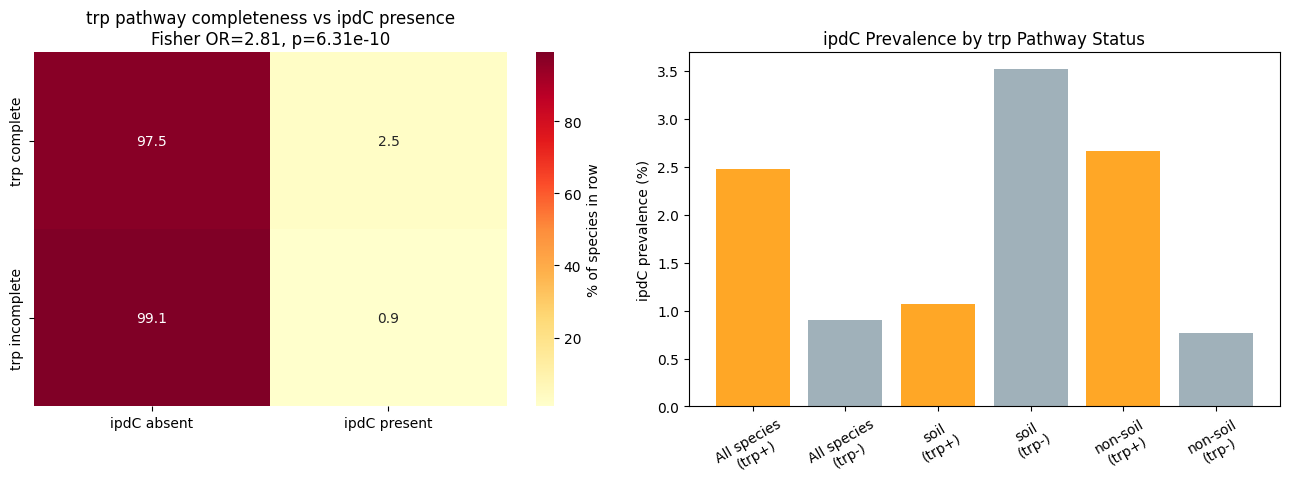

Saved figures/trp_iaa_contingency.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: contingency table as heatmap (normalized)
ax = axes[0]
ctab_norm = pd.crosstab(
    df['trp_complete_binary'].map({0: 'trp incomplete', 1: 'trp complete'}),
    df['ipdC_present'].map({0: 'ipdC absent', 1: 'ipdC present'}),
    normalize='index'
)
sns.heatmap(ctab_norm * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of species in row'}, ax=ax)
ax.set_title(f'trp pathway completeness vs ipdC presence\n'
             f'Fisher OR={or_fisher:.2f}, p={p_fisher:.2e}')
ax.set_xlabel('')
ax.set_ylabel('')

# Right: bar chart comparing ipdC prevalence with/without trp completeness, by environment
ax = axes[1]
plot_data = [
    ('All species\n(trp+)', df[df['trp_complete_binary'] == 1]['ipdC_present'].mean() * 100),
    ('All species\n(trp-)', df[df['trp_complete_binary'] == 0]['ipdC_present'].mean() * 100),
]
for _, r in strat_df.iterrows():
    if pd.notna(r['prev_trp_complete']):
        plot_data.append((f'{r["environment"]}\n(trp+)', r['prev_trp_complete'] * 100))
    if pd.notna(r['prev_trp_incomplete']):
        plot_data.append((f'{r["environment"]}\n(trp-)', r['prev_trp_incomplete'] * 100))

labels, values = zip(*plot_data) if plot_data else ([], [])
colors_bar = ['#FF9800' if 'trp+' in l else '#90A4AE' for l in labels]
ax.bar(labels, values, color=colors_bar, alpha=0.85)
ax.set_ylabel('ipdC prevalence (%)')
ax.set_title('ipdC Prevalence by trp Pathway Status')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'trp_iaa_contingency.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/trp_iaa_contingency.png')

In [8]:
# Save results
results_summary = {
    'fisher_or': or_fisher, 'fisher_p': p_fisher,
    'n_species_analyzed': len(df)
}
results_summary.update({f'logit_{k}_{m}': v for m, d in logit_results.items() for k, v in d.items()})
if neg_ctrl_results:
    results_summary.update({f'neg_ctrl_{k}': v for k, v in neg_ctrl_results.items()})

results_df = pd.DataFrame([results_summary])
results_df.to_csv(os.path.join(DATA, 'trp_iaa_results.csv'), index=False)
if not strat_df.empty:
    strat_df.to_csv(os.path.join(DATA, 'trp_iaa_stratified.csv'), index=False)
print('Saved trp_iaa_results.csv')

print('\n=== H4 Summary: Tryptophan → IAA Coupling ===')
print(f'Fisher\'s exact: OR={or_fisher:.3f}, p={p_fisher:.2e}')
if logit_results:
    best_model = max(logit_results.keys())
    lr = logit_results[best_model]
    print(f'Logit ({lr["formula"]}): OR={lr["or"]:.3f}, p={lr["p"]:.2e}')
if neg_ctrl_results:
    print(f'Negative control (tyr): OR={neg_ctrl_results["or"]:.3f}, p={neg_ctrl_results["p"]:.2e}')
h4_supported = not np.isnan(or_fisher) and p_fisher < 0.05 and or_fisher > 1
print(f'\nH4 supported: {h4_supported}')

Saved trp_iaa_results.csv

=== H4 Summary: Tryptophan → IAA Coupling ===
Fisher's exact: OR=2.808, p=6.31e-10
Logit (ipdC_present ~ trp_complete_binary + is_soil): OR=2.874, p=7.05e-09
Negative control (tyr): OR=3.620, p=2.32e-11

H4 supported: True
